# Sharpe-ratio shrinkage: distribution of accuracy across simulated datasets

Reproduces the 4-row figure.

**Setup (one dataset)**
- $K$ strategies, track-record lengths $T_k \sim U(2, 15)$ years
- true Sharpe $\mu_k \sim \mathcal N(m_0, \tau^2)$
- observed Sharpe $S_k = \mu_k + \varepsilon_k$, $\ \varepsilon_k \sim \mathcal N(0, 1/T_k)$

**Estimator** (shrinkage toward the true average $m_0$):
$$\hat S_k = m_0 + \frac{T_k}{T_k + T_{\text{prior}}}\,(S_k - m_0)$$
$T_{\text{prior}}=0$ is the raw $S_k$; $T_{\text{prior}}\to\infty$ is equal weight. The Bayes-correct value is $1/\tau^2$.

**Metrics** (computed per dataset, then shown as a distribution over $R$ datasets):
1. $\cos(\hat S, \mu)$ over all strategies
2. $\cos(\hat S, \mu)$ over strategies with true $\mu > 0$
3. $\cos(\hat S, \mu)$ over strategies with true $\mu < 0$
4. $\cos^{+} = \cos\big(\max(\hat S, 0),\ \max(\mu, 0)\big)$: positive parts of both estimate and truth (negatives count as 0)
5. $\cos\big(\max(\hat S, 0),\ \mu\big)$: **long-only portfolio**. With uncorrelated, vol-scaled strategies and weights $w_k \propto \max(\hat S_k, 0)$, the portfolio Sharpe is $SR_p = \|\mu\|\cos(w, \mu)$; the best achievable is $w=\max(\mu,0)$
6. share of strategies with $\operatorname{sign}(\hat S_k) = \operatorname{sign}(\mu_k)$
7. share of true negatives called negative ($\hat S_k<0$ among $\mu_k<0$)
8. share of true positives called positive ($\hat S_k>0$ among $\mu_k>0$)

Equal weight = constant vector $\hat S_k = 1$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
%matplotlib inline

def kde(x, xs):
    # KDE that tolerates constant samples: draws a narrow spike instead of failing
    if np.ptp(x) < 1e-9:
        w = (xs[-1] - xs[0]) / 200
        return np.exp(-0.5 * ((xs - x.mean()) / w) ** 2) / (w * np.sqrt(2 * np.pi))
    return gaussian_kde(x)(xs)

## Parameters

In [2]:
SEED  = 11
K     = 300          # strategies per dataset
R     = 2000         # simulated datasets
M0    = 0.2          # true average Sharpe (also the shrinkage target)
TAU   = 0.2          # cross-sectional sd of true Sharpes -> Bayes T_prior = 1/TAU**2
T_MIN, T_MAX = 2, 15 # track-record length range (years)
T_PRIORS = [0, 5, 10, 15, 25, 40, 100, 300, 1000]
print("Bayes-correct T_prior =", round(1/TAU**2, 2))

Bayes-correct T_prior = 25.0


## Simulate

In [3]:
rng = np.random.default_rng(SEED)
T  = rng.uniform(T_MIN, T_MAX, (R, K))
mu = rng.normal(M0, TAU, (R, K))
S  = mu + rng.normal(0, 1, (R, K)) / np.sqrt(T)
print("share truly positive:", (mu > 0).mean().round(3))

share truly positive: 0.842


## Estimator and metrics

In [4]:
def shrink(t_prior):
    return M0 + T / (T + t_prior) * (S - M0)

def cosine(a, b):                    # row-wise cosine, one value per dataset
    na, nb = np.linalg.norm(a, axis=-1), np.linalg.norm(b, axis=-1)
    return np.sum(a * b, -1) / np.where(na * nb == 0, np.inf, na * nb)   # all-zero vector -> 0

P = (mu > 0).astype(float)           # mask: true positives
N = (mu < 0).astype(float)           # mask: true negatives

METRICS = [
    ("cos(Ŝ, μ) over all strategies",                     lambda h: cosine(h, mu)),
    ("cos(Ŝ, μ) over strategies with true Sharpe > 0",    lambda h: cosine(h * P, mu * P)),
    ("cos(Ŝ, μ) over strategies with true Sharpe < 0",    lambda h: cosine(h * N, mu * N)),
    ("cos+ = cos(max(Ŝ,0), max(μ,0))",                    lambda h: cosine(np.maximum(h, 0), np.maximum(mu, 0))),
    ("cos(max(Ŝ,0), μ)  (long-only portfolio)",           lambda h: cosine(np.maximum(h, 0), mu)),
    ("share with correct sign, sign(Ŝ) = sign(μ)",        lambda h: np.mean(np.sign(h) == np.sign(mu), -1)),
    ("true negatives called negative (share)",            lambda h: ((h < 0) & (mu < 0)).sum(-1) / (mu < 0).sum(-1)),
    ("true positives called positive (share)",            lambda h: ((h > 0) & (mu > 0)).sum(-1) / (mu > 0).sum(-1)),
]

EST = {t: shrink(t) for t in T_PRIORS}
EW  = np.ones_like(S)

## Summary table (mean across datasets)

In [5]:
import pandas as pd
rows = {("raw (0)" if t == 0 else f"T_prior={t}"): [f(EST[t]).mean() for _, f in METRICS] for t in T_PRIORS}
rows["equal weight"] = [f(EW).mean() for _, f in METRICS]
table = pd.DataFrame(rows, index=["cos all", "cos true>0", "cos true<0", "cos+", "cos long-only", "sign accuracy", "neg called neg", "pos called pos"]).T.round(3)
table.round(3)

,cos all,cos true>0,cos true<0,cos+,cos long-only,sign accuracy,neg called neg,pos called pos
raw (0),0.583,0.608,0.328,0.721,0.697,0.721,0.610,0.742
T_prior=5,0.713,0.752,0.087,0.777,0.748,0.783,0.466,0.842
T_prior=10,0.760,0.810,-0.155,0.804,0.770,0.820,0.334,0.912
T_prior=15,0.779,0.840,-0.335,0.820,0.781,0.838,0.225,0.953
T_prior=25,0.789,0.866,-0.533,0.834,0.788,0.846,0.090,0.988
T_prior=40,0.782,0.877,-0.646,0.836,0.782,0.843,0.017,0.999
T_prior=100,0.753,0.874,-0.734,0.818,0.753,0.842,0.000,1.000
T_prior=300,0.726,0.862,-0.759,0.797,0.726,0.842,0.000,1.000
T_prior=1000,0.714,0.855,-0.766,0.786,0.714,0.842,0.000,1.000
equal weight,0.708,0.852,-0.769,0.781,0.708,0.842,0.000,1.000


## Figure: violin (left) and KDE (right) for each metric
Black bar = mean; dashed green = equal-weight mean.

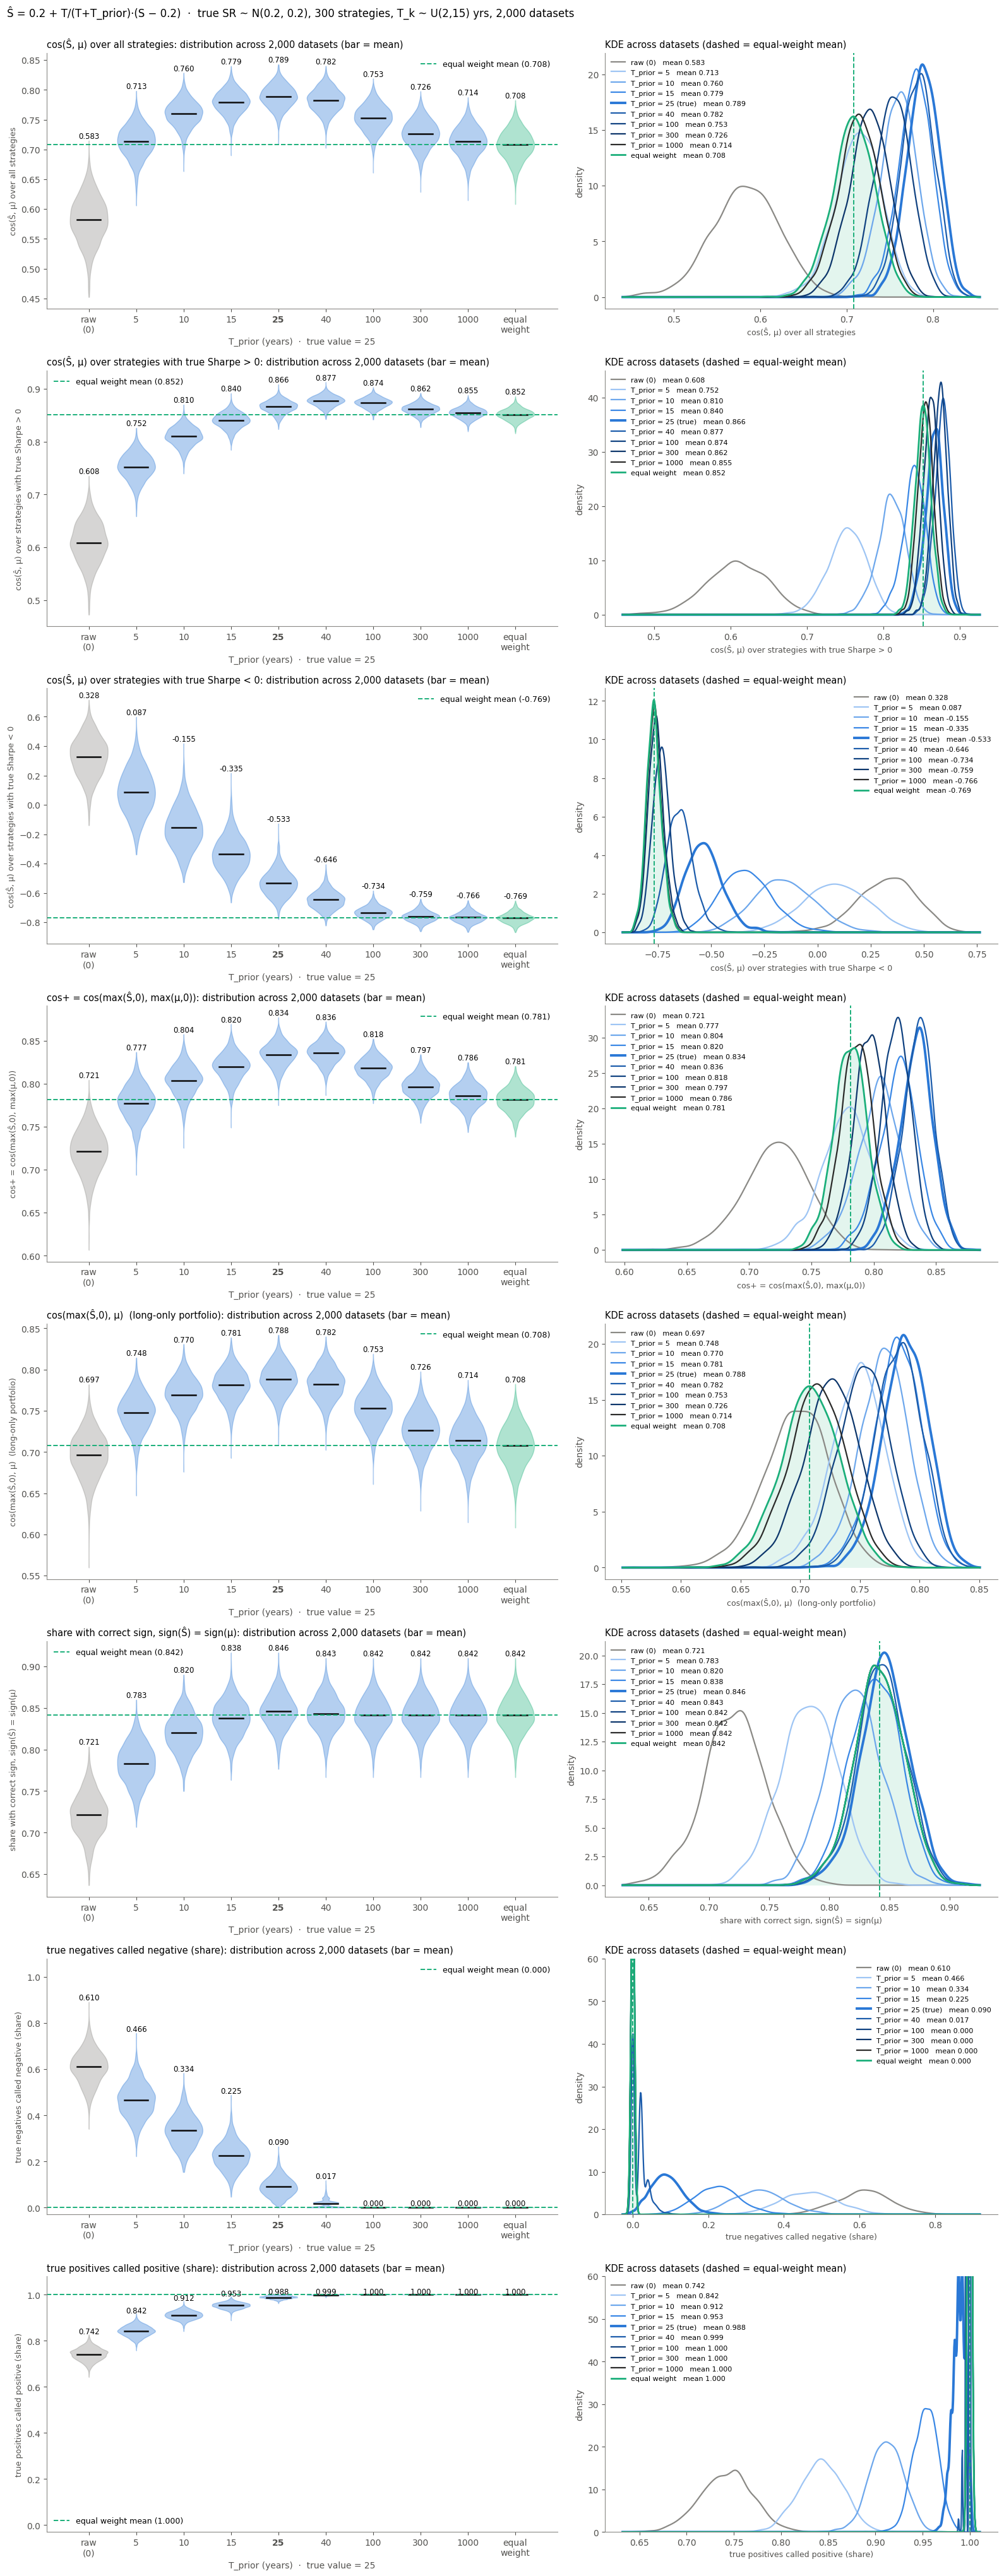

In [6]:
BLUE, GRAY, GREEN, INK, INK2 = "#2a78d6", "#8a8985", "#1baf7a", "#0b0b0b", "#52514e"
RAMP = [GRAY, "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281", "#0d366b", "#2b2b2a"]
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": GRAY, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2})
t_true = round(1 / TAU**2)

fig, ax = plt.subplots(len(METRICS), 2, figsize=(16, 5.2 * len(METRICS)), gridspec_kw={"width_ratios": [1.3, 1]})
for row, (name, f) in enumerate(METRICS):
    C  = {t: f(EST[t]) for t in T_PRIORS}
    ew = f(EW)
    a, b = ax[row]

    # --- violins
    data = [C[t] for t in T_PRIORS] + [ew]
    labs = ["raw\n(0)"] + [str(t) for t in T_PRIORS[1:]] + ["equal\nweight"]
    cols = [GRAY] + [BLUE] * (len(T_PRIORS) - 1) + [GREEN]
    vp = a.violinplot(data, showextrema=False, widths=0.8)
    for body, col in zip(vp["bodies"], cols):
        body.set_facecolor(col); body.set_edgecolor(col); body.set_alpha(0.35)
    span = max(d.max() for d in data) - min(d.min() for d in data)
    for i, d in enumerate(data, 1):
        a.plot([i - 0.25, i + 0.25], [d.mean()] * 2, color=INK, lw=1.8)
        a.text(i, d.max() + 0.01 * span, f"{d.mean():.3f}", ha="center", fontsize=8.5)
    a.axhline(ew.mean(), color=GREEN, lw=1.4, ls="--", label=f"equal weight mean ({ew.mean():.3f})")
    a.set_xticks(range(1, len(data) + 1)); a.set_xticklabels(labs)
    if t_true in T_PRIORS: a.get_xticklabels()[T_PRIORS.index(t_true)].set_fontweight("bold")
    a.set_xlabel(f"T_prior (years)  ·  true value = {t_true:.0f}"); a.set_ylabel(name, fontsize=9)
    a.set_title(f"{name}: distribution across {R:,} datasets (bar = mean)", loc="left", fontsize=10.5)
    a.legend(frameon=False, fontsize=9, loc="best")
    if row >= 6: a.set_ylim(-0.03, 1.08)

    # --- KDEs
    lo, hi = min(d.min() for d in data), max(d.max() for d in data)
    if row >= 6: b.set_ylim(0, 60)   # equal weight is a spike at 0 or 1 here
    xs = np.linspace(lo - 0.03 * (hi - lo), hi + 0.03 * (hi - lo), 800)
    for t, col in zip(T_PRIORS, RAMP):
        lab = ("raw (0)" if t == 0 else f"T_prior = {t}") + (" (true)" if t == t_true else "") + f"   mean {C[t].mean():.3f}"
        b.plot(xs, kde(C[t], xs), color=col, lw=2.8 if t == t_true else 1.6, label=lab)
    k = kde(ew, xs)
    b.plot(xs, k, color=GREEN, lw=2, label=f"equal weight   mean {ew.mean():.3f}"); b.fill_between(xs, k, color=GREEN, alpha=0.12, lw=0)
    b.axvline(ew.mean(), color=GREEN, lw=1.4, ls="--")
    b.set_xlabel(name, fontsize=9); b.set_ylabel("density")
    b.set_title("KDE across datasets (dashed = equal-weight mean)", loc="left", fontsize=10.5)
    b.legend(frameon=False, fontsize=8, loc="upper right" if row in (2, 6) else "upper left")

fig.suptitle(f"Ŝ = {M0} + T/(T+T_prior)·(S − {M0})  ·  true SR ~ N({M0}, {TAU}), {K} strategies, "
             f"T_k ~ U({T_MIN},{T_MAX}) yrs, {R:,} datasets", x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

---
# Part 2 — Approaches for negative vs positive Sharpes

All rules use the same shrinkage $m_k = m_0 + \frac{T_k}{T_k+T}(S_k-m_0)$ but treat negatives differently.

| Rule | Formula | Dial |
|---|---|---|
| **Current** | $\hat S_k = m_k$ with one $T_{\text{prior}}$ | $T_{\text{prior}}$ |
| **Two-prior (raw sign)** | $\hat S_k = m_0 + \frac{T_k}{T_k+T^{(k)}}(S_k-m_0)$, $\ T^{(k)}=T_{\text{pos}}$ if $S_k\ge0$, else $T_{\text{neg}}$ | $T_{\text{neg}}$ |
| **Posterior flag** | $\sigma_k = (T_k+T_{\text{prior}})^{-1/2}$; call negative if $P(\mu_k<0\mid S_k)=\Phi(-m_k/\sigma_k)>p \iff m_k<z\sigma_k$; output $m_k$ if not flagged, $m_k - z\sigma_k$ if flagged | $z=\Phi^{-1}(1-p)$ |
| **Equal weight** | $\hat S_k = 1$ | – |
| **Raw** | $\hat S_k = S_k$ | – |

Each dial trades *negatives called negative* against *positives called positive*. The frontier plots show every rule along its dial; up/right is better.

In [7]:
def current(t):            return shrink(t)
def two_prior(t_pos, t_neg): return M0 + T / (T + np.where(S >= 0, t_pos, t_neg)) * (S - M0)
def posterior(t0, z):
    m = shrink(t0); s = 1 / np.sqrt(T + t0)
    return np.where(m >= z * s, m, m - z * s)

T_TRUE = round(1 / TAU**2)
RULES = {                                 # name -> list of (dial value, estimate)
    "current (T_prior swept)":              [(t, current(t))              for t in [0, 2, 5, 10, 15, 25, 40, 60, 100, 300]],
    f"two-prior (T_pos={T_TRUE}, T_neg swept)": [(t, two_prior(T_TRUE, t)) for t in [0, 0.5, 1, 2, 3, 5, 7, 10, 15, 25]],
    f"posterior (T_prior={T_TRUE}, z swept)":   [(z, posterior(T_TRUE, z))  for z in [0, 0.25, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]],
}
SINGLE = {"equal weight": EW, "raw S_k": S}
NAMES = ["cos all", "cos true>0", "cos true<0", "cos+", "cos long-only", "sign accuracy", "neg called neg", "pos called pos"]

def summarize(h):
    return [f(h).mean() for _, f in METRICS]

## Table at matched sign splits

In [8]:
picks = [("equal weight", EW), (f"current T_prior={T_TRUE}", current(T_TRUE)),
         ("two-prior 25/5", two_prior(T_TRUE, 5)),   ("posterior z=0.7", posterior(T_TRUE, 0.7)),
         ("two-prior 25/2", two_prior(T_TRUE, 2)),   ("posterior z=0.8", posterior(T_TRUE, 0.8)),
         ("raw S_k", S), ("two-prior 25/0", two_prior(T_TRUE, 0)), ("posterior z=0.88", posterior(T_TRUE, 0.88))]
pd.DataFrame({n: summarize(h) for n, h in picks}, index=NAMES).T.round(3)

,cos all,cos true>0,cos true<0,cos+,cos long-only,sign accuracy,neg called neg,pos called pos
equal weight,0.708,0.852,-0.769,0.781,0.708,0.842,0.000,1.000
current T_prior=25,0.789,0.866,-0.533,0.834,0.788,0.846,0.090,0.988
two-prior 25/5,0.706,0.759,0.115,0.803,0.769,0.783,0.466,0.842
posterior z=0.7,0.764,0.824,-0.204,0.816,0.777,0.784,0.464,0.844
two-prior 25/2,0.611,0.658,0.295,0.795,0.761,0.749,0.553,0.786
posterior z=0.8,0.748,0.801,-0.105,0.805,0.769,0.753,0.545,0.792
raw S_k,0.583,0.608,0.328,0.721,0.697,0.721,0.610,0.742
two-prior 25/0,0.473,0.508,0.400,0.792,0.759,0.721,0.610,0.742
posterior z=0.88,0.729,0.777,-0.019,0.793,0.760,0.722,0.609,0.743


## Trade-off frontiers
x-axis: share of true negatives called negative. Each curve is one rule moved along its dial; markers are single rules.

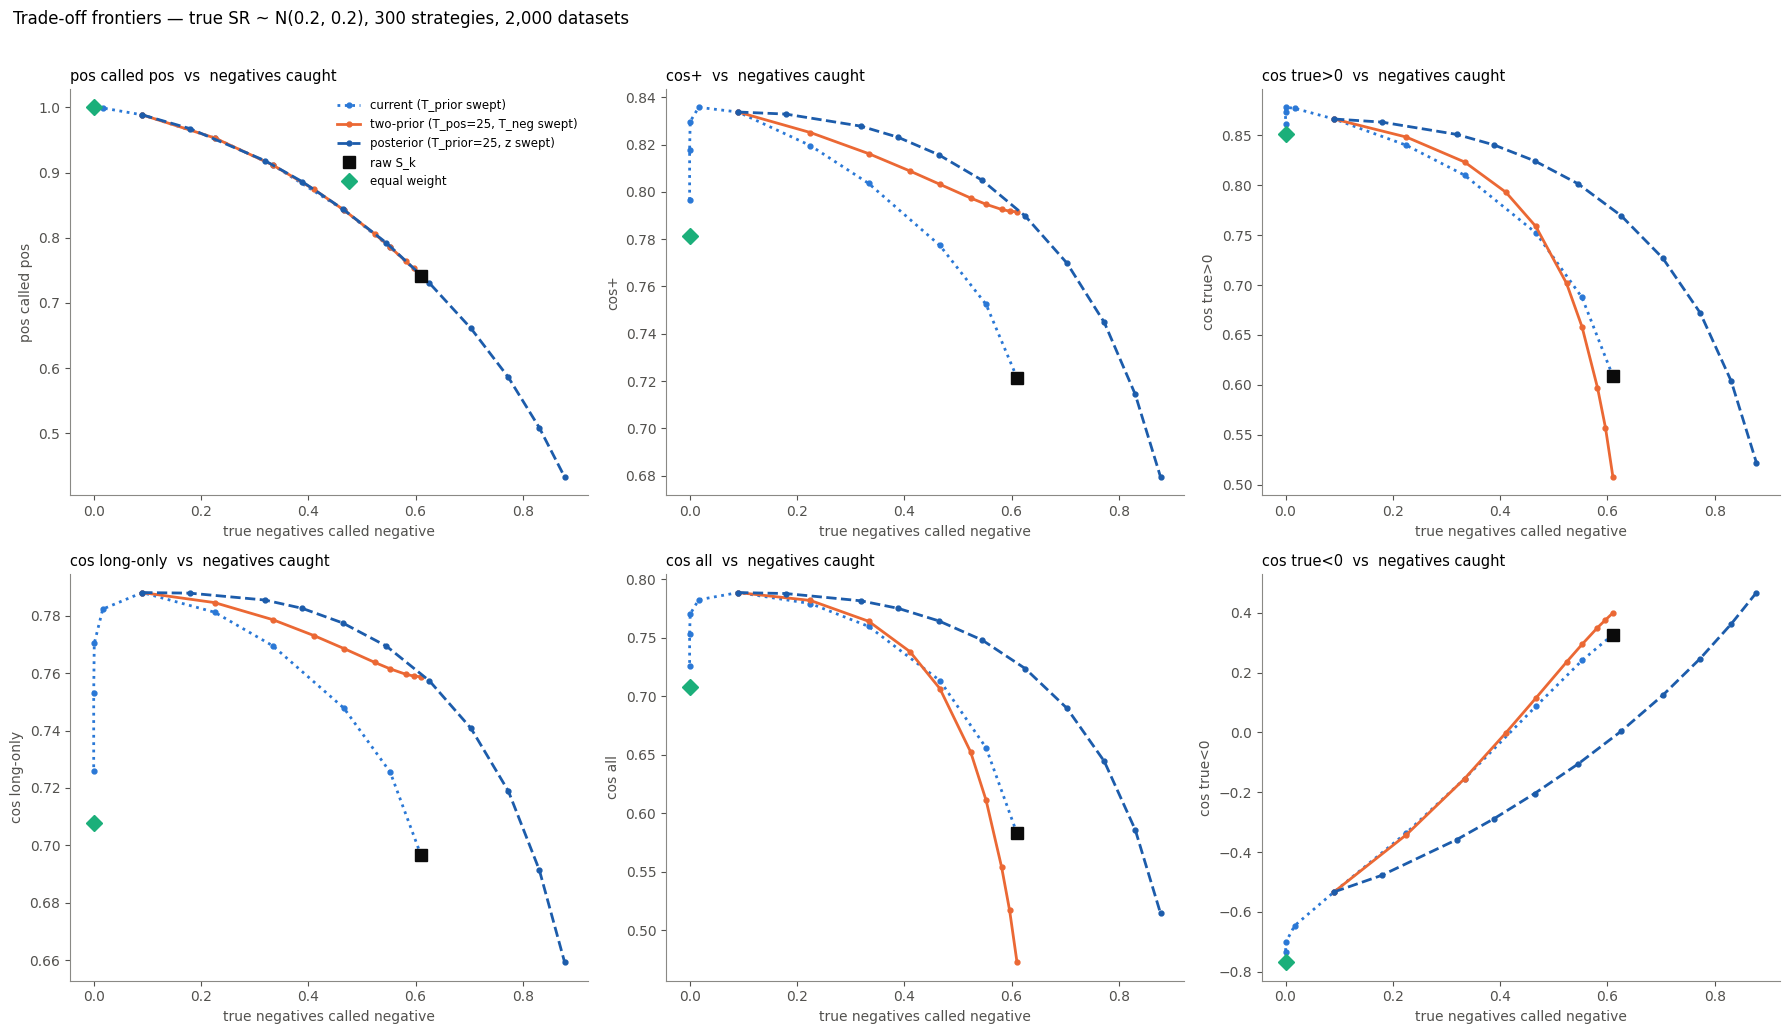

In [9]:
FRONT_Y = ["pos called pos", "cos+", "cos true>0", "cos long-only", "cos all", "cos true<0"]
COL = {"current": BLUE, "two-prior": "#eb6834", "posterior": "#1c5cab"}
LS  = {"current": ":", "two-prior": "-", "posterior": "--"}
res = {k: [(d, summarize(h)) for d, h in L] for k, L in RULES.items()}
single = {k: summarize(h) for k, h in SINGLE.items()}
ix = NAMES.index("neg called neg")

fig, ax = plt.subplots(2, 3, figsize=(18, 10.5))
for a, yname in zip(ax.flat, FRONT_Y):
    iy = NAMES.index(yname)
    for k, L in res.items():
        fam = k.split(" ")[0]
        a.plot([v[ix] for _, v in L], [v[iy] for _, v in L], color=COL[fam], ls=LS[fam], lw=2, marker="o", ms=3.5, label=k)
    a.plot(single["raw S_k"][ix], single["raw S_k"][iy], "s", color=INK, ms=8, label="raw S_k")
    a.plot(single["equal weight"][ix], single["equal weight"][iy], "D", color=GREEN, ms=8, label="equal weight")
    a.set_xlabel("true negatives called negative"); a.set_ylabel(yname)
    a.set_title(f"{yname}  vs  negatives caught", loc="left", fontsize=10.5)
ax.flat[0].legend(frameon=False, fontsize=8.5)
fig.suptitle(f"Trade-off frontiers — true SR ~ N({M0}, {TAU}), {K} strategies, {R:,} datasets", x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()

## Long-only portfolio: which rule to use
Portfolio Sharpe relative to the oracle long-only portfolio $w=\max(\mu,0)$ (uncorrelated, vol-scaled strategies).

In [10]:
best = np.linalg.norm(np.maximum(mu, 0), axis=-1)
def sr_ratio(h):
    w = np.maximum(h, 0)
    return (np.sum(w * mu, -1) / np.linalg.norm(w, axis=-1) / best)

cands = [("equal weight", EW), ("raw S_k", S)] + \
        [(f"current T={t}", current(t)) for t in [10, 15, 25, 40, 60, 100]] + \
        [("two-prior 25/5", two_prior(T_TRUE, 5)), ("two-prior 25/0", two_prior(T_TRUE, 0))] + \
        [(f"posterior z={z}", posterior(T_TRUE, z)) for z in [0.5, 0.7, 0.88]]
port = pd.DataFrame({n: {"SR / oracle SR (mean)": sr_ratio(h).mean(),
                         "5%": np.percentile(sr_ratio(h), 5), "95%": np.percentile(sr_ratio(h), 95),
                         "strategies held": np.mean(h > 0), "true negatives held": np.sum((h > 0) & (mu < 0)) / np.sum(mu < 0)}
                     for n, h in cands}).T
port.round(3)

,SR / oracle SR (mean),5%,95%,strategies held,true negatives held
equal weight,0.721,0.684,0.757,1.000,1.000
raw S_k,0.710,0.663,0.752,0.686,0.389
current T=10,0.784,0.750,0.816,0.873,0.666
current T=15,0.796,0.765,0.825,0.925,0.775
current T=25,0.803,0.774,0.830,0.976,0.909
current T=40,0.797,0.768,0.824,0.996,0.983
current T=60,0.785,0.755,0.813,1.000,0.999
current T=100,0.767,0.736,0.797,1.000,1.000
two-prior 25/5,0.783,0.749,0.815,0.794,0.533
two-prior 25/0,0.773,0.737,0.807,0.686,0.389


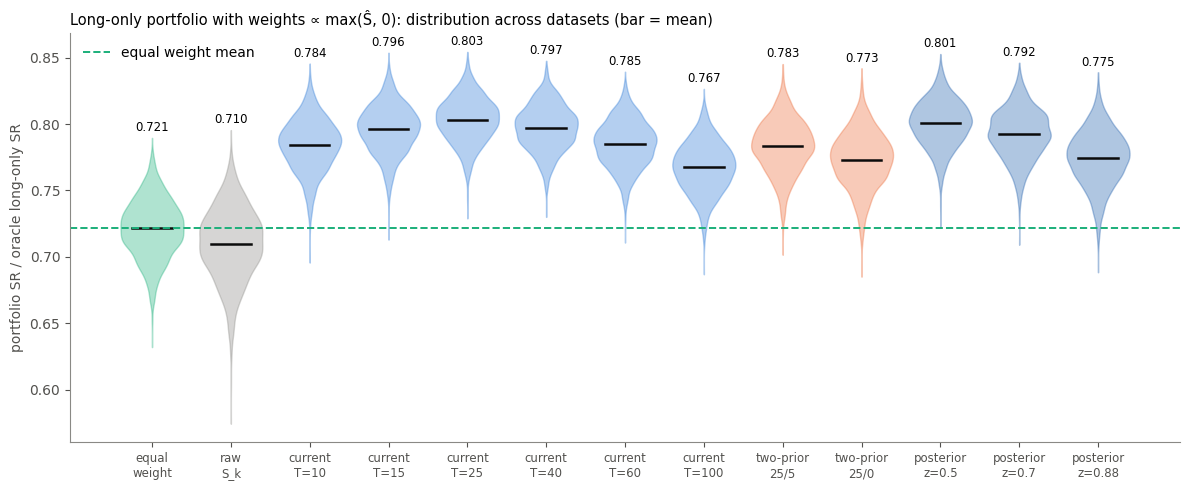

In [11]:
fig, a = plt.subplots(figsize=(12, 5))
data = [sr_ratio(h) for _, h in cands]
vp = a.violinplot(data, showextrema=False, widths=0.8)
for body, (n, _) in zip(vp["bodies"], cands):
    col = GREEN if n == "equal weight" else GRAY if n == "raw S_k" else COL[n.split(" ")[0].split("-")[0] if not n.startswith("two") else "two-prior"]
    body.set_facecolor(col); body.set_edgecolor(col); body.set_alpha(0.35)
for i, d in enumerate(data, 1):
    a.plot([i - 0.25, i + 0.25], [d.mean()] * 2, color=INK, lw=1.8); a.text(i, d.max() + 0.005, f"{d.mean():.3f}", ha="center", fontsize=8.5)
a.axhline(sr_ratio(EW).mean(), color=GREEN, ls="--", lw=1.4, label="equal weight mean")
a.set_xticks(range(1, len(cands) + 1)); a.set_xticklabels([n.replace(" ", "\n", 1) for n, _ in cands], fontsize=8.5)
a.set_ylabel("portfolio SR / oracle long-only SR"); a.legend(frameon=False)
a.set_title("Long-only portfolio with weights ∝ max(Ŝ, 0): distribution across datasets (bar = mean)", loc="left", fontsize=10.5)
plt.tight_layout(); plt.show()

**Reading:** for long-only allocation the Bayes rule is $w_k \propto \max(m_k, 0)$ with the true $T_{\text{prior}}$ — it maximizes expected return $w\cdot\mathbb E[\mu\mid S]$ for a given $\|w\|$. Flagging more strategies as negative (two-prior, posterior with larger $z$) improves sign accuracy on negatives but drops strategies whose expected Sharpe is still positive, lowering the portfolio Sharpe.